
---

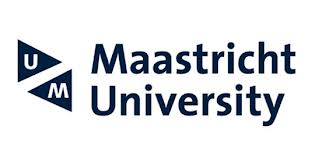


# Faculty of Science and Engineering — Department of Advanced Computing Sciences

# ANLP 2026-2027 — Assignment 3: NLP Applications

**Covers:** Tutorials 12 (Multi-Modal), 13 (Speech), 14 (Abstracting & MT), 15 (Dialog), 16 (Agents)

⏱️ **Estimated time:** 1.6 hours – 3.5 hours

By Jan Scholtes — Version 2026-2027

---

**Instructions:**
- This is a **graded assignment** worth 80 points
- You will build a multi-modal information assistant that can summarize, translate, and converse
- Each exercise builds on concepts from multiple tutorials
- Fill in the `# TODO` sections and write your answers where indicated
- Do **not** modify test cells

**Time estimate:** ~4-5 hours

**Scenario:** You are building components for a multilingual information assistant that can:
1. Summarize documents (T14)
2. Translate content (T14)
3. Answer questions conversationally (T15)
4. Explain its own capabilities (T12 + T16)

## Setup

In [ ]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Knowledge base: paragraphs about renewable energy (used throughout the assignment)
knowledge_base = [
    "Solar energy is one of the fastest-growing renewable energy sources worldwide. "
    "Photovoltaic panels convert sunlight directly into electricity using semiconductor materials. "
    "The cost of solar panels has dropped by over 90 percent since 2010, making it competitive with fossil fuels.",

    "Wind power generates electricity by using large turbines that capture kinetic energy from moving air. "
    "Offshore wind farms are becoming increasingly popular because wind speeds over the ocean are stronger and more consistent. "
    "Denmark currently produces over 50 percent of its electricity from wind energy.",

    "Hydroelectric power harnesses the energy of flowing water to generate electricity. "
    "Large dams store water in reservoirs and release it through turbines when electricity is needed. "
    "Hydropower is the oldest and most established form of renewable energy, providing about 16 percent of global electricity.",

    "Geothermal energy taps into heat stored beneath the earth's surface to generate electricity and provide heating. "
    "Iceland generates nearly 100 percent of its electricity from renewable sources, with geothermal providing about 25 percent. "
    "Geothermal plants have a very small land footprint compared to solar and wind farms.",

    "Battery storage technology is critical for making renewable energy reliable and dispatchable. "
    "Lithium-ion batteries currently dominate the market, but solid-state batteries promise higher energy density. "
    "Grid-scale battery installations grew by 80 percent in 2023, enabling better integration of intermittent renewables.",

    "Green hydrogen produced by electrolysis using renewable electricity is emerging as a key energy carrier. "
    "Hydrogen can store excess renewable energy and be used in fuel cells for transportation and industry. "
    "The European Union aims to produce 10 million tonnes of green hydrogen annually by 2030.",
]

print(f"Knowledge base: {len(knowledge_base)} paragraphs")
for i, p in enumerate(knowledge_base):
    print(f"  [{i}] {p[:80]}...")import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import transformers
transformers.logging.set_verbosity_error()
from datasets import disable_progress_bar
disable_progress_bar()


# Exercises

## Exercise A1: Summarization & Translation (20 points)

*Integrates: Tutorial 14 (Abstracting & Machine Translation)*

**a)** (12 points — code) Build a two-stage pipeline:
1. **Extractive summarization**: Complete `extractive_summary(paragraphs, k=3)` using TF-IDF to select the `k` most important sentences across all paragraphs
2. **Translation**: Translate the summary from English to German using a Helsinki-NLP model

**b)** (8 points — explanation) Compare extractive vs abstractive summarization for this knowledge base.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

def extractive_summary(paragraphs, k=3):
    """Select the k most representative sentences using TF-IDF.
    Returns: list of k sentence strings, sorted by importance (most important first)."""
    # Step 1: split all paragraphs into individual sentences
    all_sentences = []
    for p in paragraphs:
        all_sentences.extend(sent_tokenize(p))

    # TODO: build TF-IDF matrix for all sentences
    # TODO: compute the centroid vector (mean of all sentence vectors)
    # TODO: compute cosine similarity of each sentence to the centroid
    # TODO: return top-k sentences sorted by similarity (descending)
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

summary_sentences = extractive_summary(knowledge_base, k=3)
print("Extractive Summary (top 3 sentences):")
for i, s in enumerate(summary_sentences):
    print(f"  {i+1}. {s}")

In [ ]:
from transformers import MarianMTModel, MarianTokenizer

# Translate the summary to German
mt_model_name = "Helsinki-NLP/opus-mt-en-de"
mt_tokenizer = MarianTokenizer.from_pretrained(mt_model_name)
mt_model = MarianMTModel.from_pretrained(mt_model_name)

def translate_en_de(text):
    """Translate English text to German."""
    # TODO: tokenize the text, generate translation, decode and return
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

# Translate summary
summary_text = " ".join(summary_sentences)
translated_summary = translate_en_de(summary_text)
print(f"English summary:\n{summary_text}\n")
print(f"German translation:\n{translated_summary}")

In [ ]:
# AUTO-GRADED TESTS (12 points)
# Do not modify this cell



### A1 Explanation (8 points — manually graded)

Compare extractive vs abstractive summarization for this knowledge base. Answer the following:

1. How does each approach work (extractive TF-IDF centroid vs abstractive e.g. Pegasus)?
2. How does output quality compare?
3. How faithful is each approach to the source text?
4. When would you prefer each approach?
5. Is the TF-IDF centroid method a good choice for this knowledge base? Why or why not? (2-3 sentences)

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A2: Retrieval-Based Q&A System (20 points)

*Integrates: Tutorial 15 (Dialog) + Tutorial 14 (Abstracting & MT)*

**a)** (12 points — code) Build a retrieval-based Q&A function that:
1. Takes a user question
2. Finds the most relevant paragraph from the knowledge base using TF-IDF + cosine similarity
3. Returns both the answer paragraph and a confidence score

Create a `qa_system(question)` function and test it with 5 questions.

**b)** (8 points — explanation) What are the NLU, NLG, and DM components of this system?

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# Pre-compute TF-IDF for knowledge base
kb_vectorizer = TfidfVectorizer(stop_words="english")
kb_tfidf = kb_vectorizer.fit_transform(knowledge_base)

def qa_system(question):
    """Answer a question using the knowledge base.
    Returns: dict with 'answer' (str), 'confidence' (float), 'source_idx' (int)"""
    # TODO: transform question using kb_vectorizer
    # TODO: compute cosine similarity with all KB paragraphs
    # TODO: find best matching paragraph
    # TODO: return dict with answer, confidence score, and source paragraph index
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

# Test with 5 questions
test_questions = [
    "How does solar energy work?",
    "What country uses the most wind power?",
    "Tell me about battery storage for renewables",
    "What is green hydrogen used for?",
    "How does hydroelectric power generate electricity?"
]

qa_results = []
for q in test_questions:
    result = qa_system(q)
    qa_results.append(result)
    print(f"Q: {q}")
    print(f"A: {result['answer'][:100]}...")
    print(f"   Confidence: {result['confidence']:.4f} | Source: paragraph {result['source_idx']}\n")

In [ ]:
# AUTO-GRADED TESTS (12 points)
# Do not modify this cell



### A2 Explanation (8 points — manually graded)

Identify the NLU, NLG, and DM components of this Q&A system. Answer the following:

1. What is the NLU component? Describe its implementation and its main limitation.
2. What is the NLG component? Describe its implementation and its main limitation.
3. What is the DM (dialogue management) component? Describe its implementation and its main limitation.
4. How would you improve this system using RAG (Retrieval Augmented Generation)? (3-4 sentences)

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A3: Multi-Modal Understanding (20 points)

*Integrates: Tutorial 12 (Multi-Modal Models) + Tutorial 13 (Speech Recognition)*

**a)** (12 points — code) Use CLIP to match images of energy sources with text descriptions. Given 5 image URLs and 6 text labels, compute the CLIP similarity matrix and determine the best text match for each image.

**b)** (8 points — explanation) How does CLIP's contrastive learning enable zero-shot classification?

In [ ]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests
from io import BytesIO
import torch

# Load CLIP
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()
print("CLIP model loaded")

In [ ]:
# Energy-related text labels
energy_labels = [
    "solar panels on a rooftop generating electricity from sunlight",
    "wind turbines in an offshore wind farm on the ocean",
    "a large hydroelectric dam with water flowing through turbines",
    "a geothermal power plant with steam rising from the ground",
    "rows of lithium-ion batteries in a grid-scale storage facility",
    "an industrial green hydrogen electrolysis plant",
]

# Since we can't guarantee image URLs work, we create synthetic "images"
# by rendering text descriptions as solid-colored images with labels
# (In a real scenario, these would be actual photos)
def create_test_image(color, size=(224, 224)):
    """Create a simple colored test image."""
    return Image.new("RGB", size, color)

test_images = [
    create_test_image((255, 223, 0)),   # yellow = solar
    create_test_image((135, 206, 235)), # sky blue = wind
    create_test_image((0, 105, 148)),   # deep blue = hydro
    create_test_image((178, 34, 34)),   # firebrick = geothermal
    create_test_image((169, 169, 169)), # gray = batteries
]
image_names = ["solar", "wind", "hydro", "geothermal", "batteries"]

# TODO: compute CLIP similarity matrix between images and text labels
# TODO: for each image, find the best matching text label
# TODO: store results in clip_results: list of dicts with
#        {"image": str, "best_label": str, "score": float}
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# AUTO-GRADED TESTS (12 points)
# Do not modify this cell



### A3 Explanation (8 points — manually graded)

How does CLIP's contrastive learning enable zero-shot classification? Answer the following:

1. What is CLIP's training objective?
2. How are images and text compared in CLIP?
3. Why does CLIP work for zero-shot classification?
4. What is the main limitation of CLIP?
5. How could you combine CLIP with the Q&A system from A2 to build a multi-modal assistant? (2-3 sentences)

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A4: Agent Architecture Design (20 points)

*Integrates: Tutorial 16 (Agents) + Tutorial 15 (Dialog)*

**a)** (10 points — code) Build a simple agent dispatcher that routes user queries to the appropriate tool from the previous exercises. Complete the `agent_dispatch(query)` function that:
1. Classifies the query intent (summarize / translate / question / compare)
2. Calls the appropriate function
3. Returns the result with metadata

**b)** (10 points — explanation) Design a multi-agent system for a renewable energy information service.

In [ ]:
def classify_intent(query):
    """Classify user query intent using keyword matching.
    Returns: one of 'summarize', 'translate', 'question', 'compare'"""
    query_lower = query.lower()
    if any(w in query_lower for w in ["summarize", "summary", "main points", "overview"]):
        return "summarize"
    elif any(w in query_lower for w in ["translate", "german", "deutsch", "translation"]):
        return "translate"
    elif any(w in query_lower for w in ["compare", "difference", "versus", "vs", "better"]):
        return "compare"
    else:
        return "question"

def agent_dispatch(query):
    """Route query to appropriate tool and return result.
    Returns: dict with 'intent', 'query', 'response', 'tool_used'"""
    intent = classify_intent(query)
    
    # TODO: based on intent, call the appropriate function:
    #   - "summarize": call extractive_summary(knowledge_base, k=3) and join sentences
    #   - "translate": call translate_en_de on the query (after removing "translate" keyword)
    #   - "question": call qa_system(query) and return the answer
    #   - "compare": call qa_system(query) and return with a note about comparison
    # TODO: return dict with 'intent', 'query', 'response' (str), 'tool_used' (str)
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

# Test with various queries
agent_queries = [
    "Give me a summary of renewable energy",
    "Translate the main points to German",
    "How does wind power work?",
    "What is the difference between solar and wind energy?",
    "Tell me about battery storage technology",
]

agent_results = []
for q in agent_queries:
    result = agent_dispatch(q)
    agent_results.append(result)
    print(f"Query: {q}")
    print(f"Intent: {result['intent']} | Tool: {result['tool_used']}")
    print(f"Response: {result['response'][:120]}...\n")

In [ ]:
# AUTO-GRADED TESTS (10 points)
# Do not modify this cell



### A4 Explanation (10 points — manually graded)

Design a multi-agent system for the renewable energy information service. Answer the following:

1. Describe the **Router Agent**: what is its role, what input does it take, what does it output, and what tools does it use?
2. Describe the **Research Agent**: what is its role, what input does it take, what does it output, and what tools does it use?
3. Describe the **Translation Agent**: what is its role, what input does it take, what does it output, and what tools does it use?
4. Describe the **Fact-Check Agent**: what is its role, what input does it take, what does it output, and what tools does it use?
5. How would this multi-agent system handle the query "Summarize the latest wind energy developments and translate to German, but verify the facts first"? Describe the agent interaction step by step. (4-5 sentences)

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Summary

In this assignment you built a multi-modal information assistant:

1. **Summarization & Translation** (T14): TF-IDF extractive summarization → neural machine translation
2. **Retrieval-Based Q&A** (T15): TF-IDF knowledge base search with confidence scoring
3. **Multi-Modal Understanding** (T12): CLIP zero-shot image-text matching
4. **Agent Architecture** (T16+T15): Intent-based query routing to specialized tools

**Total: 80 points** (46 auto-graded + 34 manually graded)